<a href="https://colab.research.google.com/github/Marcel-12345/PCVK_Ganjil_2026/blob/main/PCVKWeek5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : Anselmus Marcel Putra Andria
NIM : 244107020141 | N = 141
bins   : 16
clip   : 1.5
tile   : 3
L      : 2
WAKTU : 2026-09-26 21:17:27 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 4dce3eb274ee02f3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pertanyaan praktikum 1
=== UJI PERBANDINGAN HISTOGRAM: lena.jpg ===
Gagal memuat gambar: lena.jpg. Pastikan file tersedia.
=== UJI PERBANDINGAN HISTOGRAM: KTM1b.jpg ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0
-> PEMBUKTIAN BERHASIL: Ketiga metode menghasilkan nilai yang identik (selisih = 0).



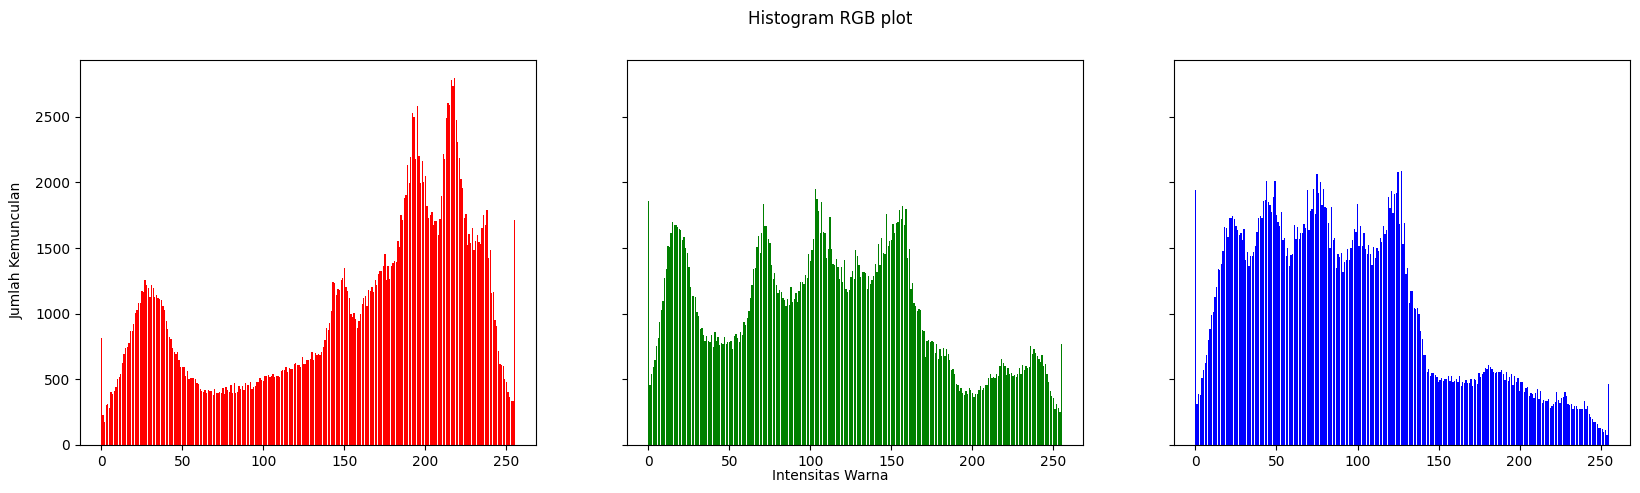

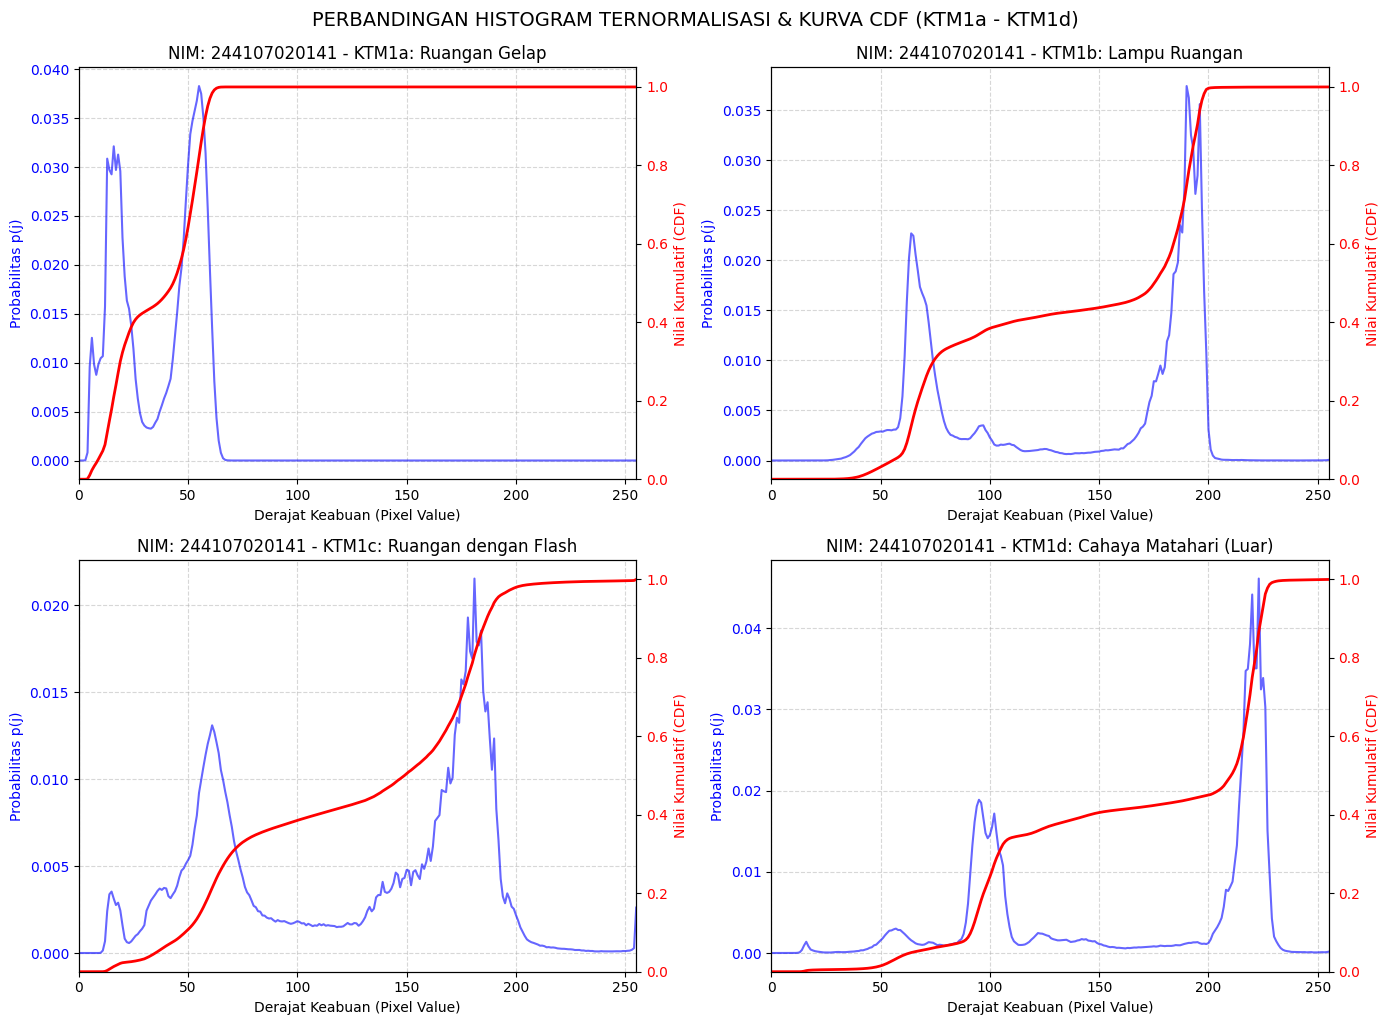

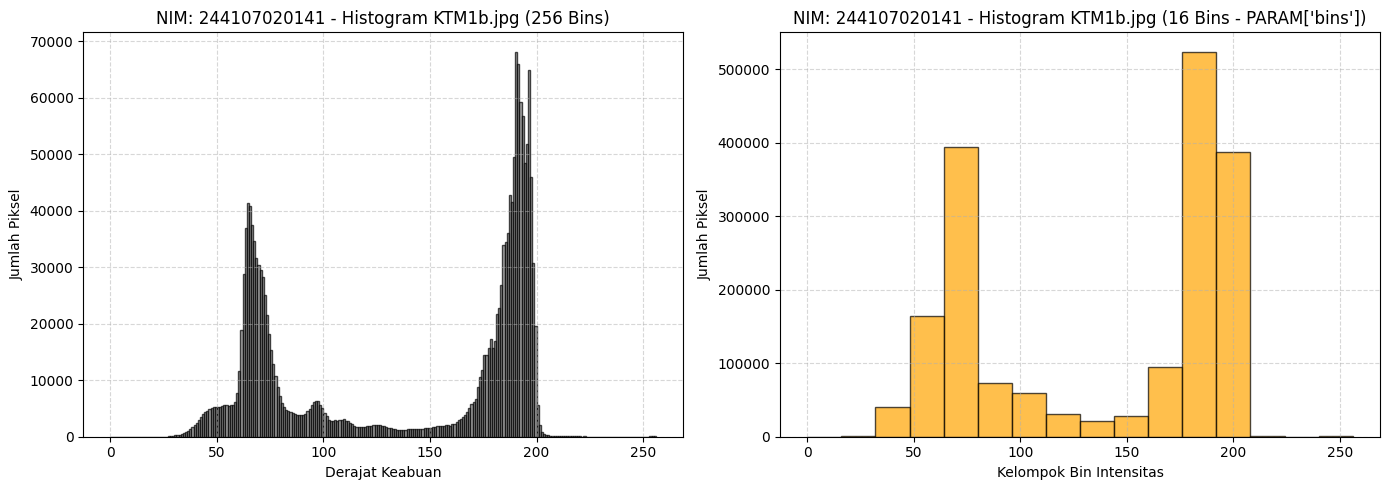

'\nANALISIS SOAL 3:\nInformasi yang hilang saat jumlah bin dikurangi:\nKetika jumlah bin dikurangi dari 256 menjadi {num_bins} bin, terjadi pengelompokan \n(binning/quantization) beberapa nilai intensitas piksel yang berdekatan ke dalam \nsatu interval bin yang sama. \n\nInformasi detail mengenai variasi pencahayaan halus (fine details), kontras mikro, \ndan fluktuasi distribusi intensitas spesifik antar-nilai piksel tunggal menjadi hilang/tersamar. \nHistogram menjadi lebih mulus (smooth) dan tergeneralisasi, sehingga kita tidak lagi \ndapat melihat frekuensi persis dari masing-masing tingkat keabuan (0-255).\n'

In [2]:
# SEL IDENTITAS
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Anselmus Marcel Putra Andria'
NIM = '244107020141'
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

# IMPORT
from google.colab import drive
drive.mount('/content/drive')
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Membuat histogram image (manual)
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
blue = [0]*256
green = [0]*256
for y in range(0,height):
  for x in range(0,width):
    red[img[y][x] [0]] += 1
    green[img[y][x] [1]] += 1
    blue[img[y][x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex = True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

# PERTANYAAN PRAKTIKUM 1
print("Pertanyaan praktikum 1")

# ==============================================================================
# SETUP AWAL & DEFINISI FUNGSI HISTOGRAM MANUAL
# ==============================================================================
# Path direktori penyimpanan gambar (sesuaikan jika menggunakan Google Drive)
BASE_PATH = '/content/drive/MyDrive/PCVK/Images/244107020141/'

def histogram_manual(img, L=256):
    """Fungsi histogram manual sesuai modul teori[cite: 1]"""
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

# ==============================================================================
# SOAL 1: PERBANDINGAN HISTOGRAM MANUAL, NUMPY, DAN OPENCV
# ==============================================================================
def uji_perbandingan_histogram(filename):
    print(f"=== UJI PERBANDINGAN HISTOGRAM: {filename} ===")

    # 1. Load Citra (Grayscale)
    img = cv.imread(BASE_PATH + filename, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Gagal memuat gambar: {filename}. Pastikan file tersedia.")
        return

    # 2. Perhitungan Histogram dengan 3 Metode
    hist_manual = histogram_manual(img)
    hist_numpy, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])
    hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).ravel()

    # 3. Hitung Selisih Maksimum
    diff_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
    diff_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    diff_numpy_cv = np.max(np.abs(hist_numpy - hist_cv))

    # 4. Tampilkan Hasil Pembuktian
    print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_numpy}")
    print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}")
    print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_numpy_cv}")

    if diff_manual_numpy == 0 and diff_manual_cv == 0:
        print("-> PEMBUKTIAN BERHASIL: Ketiga metode menghasilkan nilai yang identik (selisih = 0).\n")
    else:
        print("-> PEMBUKTIAN GAGAL: Terdapat perbedaan pada hasil perhitungan.\n")

# Eksekusi Soal 1
uji_perbandingan_histogram('lena.jpg')   # Uji pada lena.jpg[cite: 2]
uji_perbandingan_histogram('KTM1b.jpg')  # Ulangi pada KTM1b.jpg[cite: 2]


# ==============================================================================
# SOAL 2: HISTOGRAM TERNORMALISASI p(j) & KURVA CDF (2x2 FIGURE)
# ==============================================================================
ktm_files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
ktm_titles = [
    'KTM1a: Ruangan Gelap',
    'KTM1b: Lampu Ruangan',
    'KTM1c: Ruangan dengan Flash',
    'KTM1d: Cahaya Matahari (Luar)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, filename in enumerate(ktm_files):
    img = cv.imread(BASE_PATH + filename, cv.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # Hitung Histogram, Normalisasi p(j), dan CDF
    h = cv.calcHist([img], [0], None, [256], [0, 256]).ravel()
    p_j = h / img.size
    cdf = np.cumsum(p_j)

    # Sumbu X (Derajat Keabuan 0-255)
    bins_x = np.arange(256)

    # Plotting p(j) pada Sumbu Kiri (Bar/Line)
    ax1 = axes[i]
    ax1.plot(bins_x, p_j, color='blue', alpha=0.6, label='Histogram Ternormalisasi p(j)')
    ax1.set_xlabel('Derajat Keabuan (Pixel Value)')
    ax1.set_ylabel('Probabilitas p(j)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xlim([0, 255])

    # Plotting CDF pada Sumbu Kanan (Sumbu Ganda)
    ax2 = ax1.twinx()
    ax2.plot(bins_x, cdf, color='red', linewidth=2, label='Kurva CDF')
    ax2.set_ylabel('Nilai Kumulatif (CDF)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 1.05])

    # Judul Gambar (Termasuk NIM dari variabel PARAM/NIM jika tersedia)
    title_prefix = f"NIM: {NIM} - " if 'NIM' in globals() else ""
    ax1.set_title(f"{title_prefix}{ktm_titles[i]}")
    ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('PERBANDINGAN HISTOGRAM TERNORMALISASI & KURVA CDF (KTM1a - KTM1d)', fontsize=14, y=1.02)
plt.show()

# --- PENJELASAN SOAL 2 (Tuliskan analisis ini pada Laporan Praktikum Anda) ---
"""
ANALISIS SOAL 2:
1. Citra Paling Gelap (KTM1a - Gelap):
   - Distribusi p(j) menumpuk di area kiri (nilai intensitas rendah/mendekati 0).
   - Kurva CDF naik sangat curam di awal (intensitas rendah) lalu mendatar
     mendekati nilai 1 sebelum mencapai pertengahan nilai piksel.
   - Kondisi Akuisisi: Minim intensitas cahaya masuk ke sensor kamera, sehingga
     sebagian besar piksel bernilai gelap/hitam.

2. Citra Paling Terang (KTM1c / KTM1d - Flash / Cahaya Matahari):
   - Distribusi p(j) bergeser dominan ke area kanan (nilai intensitas tinggi/mendekati 255).
   - Kurva CDF bernilai mendekati 0 di awal, lalu melonjak curam di area intensitas
     terang (kanan) hingga mencapai nilai 1.
   - Kondisi Akuisisi: Pencahayaan tinggi/berlebih saat pengambilan gambar
     membuat piksel terdominasi oleh warna terang/putih.
"""


# ==============================================================================
# SOAL 3: PERBANDINGAN HISTOGRAM BINS PARAM['bins'] VS 256 BINS
# ==============================================================================
# Mengambil nilai PARAM['bins'] dari Sel Identitas, jika belum ada default ke 32
num_bins = PARAM['bins'] if 'PARAM' in globals() and 'bins' in PARAM else 32

img_ktm1b = cv.imread(BASE_PATH + 'KTM1b.jpg', cv.IMREAD_GRAYSCALE)

if img_ktm1b is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    title_prefix = f"NIM: {NIM} - " if 'NIM' in globals() else ""

    # 1. Histogram dengan 256 Bins
    axes[0].hist(img_ktm1b.ravel(), bins=256, range=[0, 256], color='gray', edgecolor='black', alpha=0.7)
    axes[0].set_title(f"{title_prefix}Histogram KTM1b.jpg (256 Bins)")
    axes[0].set_xlabel('Derajat Keabuan')
    axes[0].set_ylabel('Jumlah Piksel')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Histogram dengan PARAM['bins']
    axes[1].hist(img_ktm1b.ravel(), bins=num_bins, range=[0, 256], color='orange', edgecolor='black', alpha=0.7)
    axes[1].set_title(f"{title_prefix}Histogram KTM1b.jpg ({num_bins} Bins - PARAM['bins'])")
    axes[1].set_xlabel('Kelompok Bin Intensitas')
    axes[1].set_ylabel('Jumlah Piksel')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- PENJELASAN SOAL 3 (Tuliskan analisis ini pada Laporan Praktikum Anda) ---
"""
ANALISIS SOAL 3:
Informasi yang hilang saat jumlah bin dikurangi:
Ketika jumlah bin dikurangi dari 256 menjadi {num_bins} bin, terjadi pengelompokan
(binning/quantization) beberapa nilai intensitas piksel yang berdekatan ke dalam
satu interval bin yang sama.

Informasi detail mengenai variasi pencahayaan halus (fine details), kontras mikro,
dan fluktuasi distribusi intensitas spesifik antar-nilai piksel tunggal menjadi hilang/tersamar.
Histogram menjadi lebih mulus (smooth) dan tergeneralisasi, sehingga kita tidak lagi
dapat melihat frekuensi persis dari masing-masing tingkat keabuan (0-255).
"""
